# FedProp Experiments — Results Analysis

This notebook loads all experiment CSVs and produces analysis and visualizations across:
- **R1**: GCN across Cora / Citeseer / Pubmed (propagation × beta × hop)
- **R1b**: GAT across the same datasets (propagation × beta × PE)
- **Prelim runs**: per-client training curves from recent 20260508 experiments
- **Propagator eval**: convergence and beta-sensitivity curves

## 1. Setup

In [ ]:
import os, glob, ast, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

BASE = Path('/home/bosho/FP/experiments')

PROP_ORDER   = ['full', 'adjacency', 'diffusion', 'zero_hop']
PROP_LABELS  = {'full': 'Full', 'adjacency': 'Adjacency', 'diffusion': 'Diffusion', 'zero_hop': 'Zero-hop'}
DATASET_ORDER = ['Cora', 'Citeseer', 'Pubmed']
BETA_VALS    = [1, 10, 10000]

COLORS = sns.color_palette('tab10')
PROP_COLORS = {p: c for p, c in zip(PROP_ORDER, COLORS)}

print('Setup complete.')

Setup complete.


## 2. Data Loading

### 2.1 Consolidated summary tables (R1 / R1b)

In [4]:
r1  = pd.read_csv(BASE / 'output/R1_consolidated.csv')
r1b = pd.read_csv(BASE / 'output/R1b_consolidated.csv')

# Combine into one frame with a source tag
r1['source']  = 'R1'
r1b['source'] = 'R1b'
consolidated = pd.concat([r1, r1b], ignore_index=True)

# Normalise dtypes
consolidated['beta']    = consolidated['beta'].astype(int)
consolidated['use_pe']  = consolidated['use_pe'].astype(bool)
consolidated['acc_pct'] = (consolidated['mean_acc'] * 100).round(2)
consolidated['std_pct'] = (consolidated['std_acc']  * 100).round(2)

print(f'R1 rows : {len(r1)}')
print(f'R1b rows: {len(r1b)}')
print(f'Combined: {len(consolidated)}')
consolidated.head()

R1 rows : 33
R1b rows: 54
Combined: 87


,dataset,model,propagation,beta,hop,use_pe,num_clients,n_reps,mean_acc,std_acc,source,acc_pct,std_pct
0,Citeseer,GCN,adjacency,1,1,False,10,10,0.6634,0.013771,R1,66.34,1.38
1,Citeseer,GCN,adjacency,10,1,False,10,10,0.6344,0.010365,R1,63.44,1.04
2,Citeseer,GCN,adjacency,10000,1,False,10,10,0.6380,0.014636,R1,63.80,1.46
3,Citeseer,GCN,diffusion,10,1,False,10,10,0.6285,0.013559,R1,62.85,1.36
4,Citeseer,GCN,diffusion,10000,1,False,10,10,0.6262,0.014566,R1,62.62,1.46


### 2.2 Preliminary experiment runs (training CSVs — 20260508)

In [5]:
PRELIM_DIRS = [
    BASE / 'cora_results_test',
    BASE / 'citeseer_results_prelim',
    BASE / 'pubmed_results_prelim',
]

# Regex to parse folder names like:
# Cora_diffusion_GCN_beta1_clients10_hop2_iter80_t1.0_alpha0.5_pe
FOLDER_RE = re.compile(
    r'^(?P<dataset>\w+)_(?P<propagation>\w+)_(?P<model>\w+)'
    r'_beta(?P<beta>\d+)_clients(?P<num_clients>\d+)_hop(?P<hop>\d+)'
    r'_iter(?P<iter>\d+)_t(?P<t>[\d.]+)_alpha(?P<alpha>[\d.]+)(?P<pe>_pe)?$'
)

def parse_folder(folder_name):
    m = FOLDER_RE.match(folder_name)
    if not m:
        return None
    d = m.groupdict()
    return {
        'dataset':      d['dataset'],
        'propagation':  d['propagation'],
        'model':        d['model'],
        'beta':         int(d['beta']),
        'num_clients':  int(d['num_clients']),
        'hop':          int(d['hop']),
        'use_pe':       d['pe'] is not None,
    }

def load_prelim_run(csv_path):
    """Return mean final-epoch val accuracy across clients."""
    df = pd.read_csv(csv_path)
    final_accs = []
    for _, row in df.iterrows():
        try:
            epochs = ast.literal_eval(row['epochs_data'])
            # epochs_data is a list of dicts with keys like 'val_acc'
            if isinstance(epochs, list) and len(epochs) > 0:
                last = epochs[-1]
                if isinstance(last, dict) and 'val_acc' in last:
                    final_accs.append(last['val_acc'])
        except Exception:
            pass
    # Fallback: use last value of training_accuracies per client
    if not final_accs:
        for _, row in df.iterrows():
            try:
                accs = ast.literal_eval(row['training_accuracies'])
                if accs:
                    final_accs.append(accs[-1])
            except Exception:
                pass
    return (np.mean(final_accs), np.std(final_accs)) if final_accs else (np.nan, np.nan)

records = []
for prelim_dir in PRELIM_DIRS:
    for exp_folder in sorted(prelim_dir.iterdir()):
        if not exp_folder.is_dir():
            continue
        meta = parse_folder(exp_folder.name)
        if meta is None:
            continue
        csv_files = sorted(exp_folder.glob('training_*.csv'))
        if not csv_files:
            continue
        # Use the most recent file if there are multiple
        mean_acc, std_acc = load_prelim_run(csv_files[-1])
        meta.update({'mean_acc': mean_acc, 'std_acc': std_acc,
                     'acc_pct': round(mean_acc * 100, 2) if not np.isnan(mean_acc) else np.nan,
                     'std_pct': round(std_acc  * 100, 2) if not np.isnan(std_acc)  else np.nan,
                     'csv_path': str(csv_files[-1]), 'source': 'prelim'})
        records.append(meta)

prelim_df = pd.DataFrame(records)
print(f'Loaded {len(prelim_df)} prelim run entries.')
prelim_df.head()

Loaded 56 prelim run entries.


,dataset,propagation,model,beta,num_clients,hop,use_pe,mean_acc,std_acc,acc_pct,std_pct,csv_path,source
0,Cora,adjacency,GAT,10000,10,2,False,0.992857,0.021429,99.29,2.14,/home/bosho/FP/experiments/cora_results_test/C...,prelim
1,Cora,adjacency,GAT,10000,10,2,True,1.000000,0.000000,100.00,0.00,/home/bosho/FP/experiments/cora_results_test/C...,prelim
2,Cora,adjacency,GAT,1,10,2,False,0.984615,0.046154,98.46,4.62,/home/bosho/FP/experiments/cora_results_test/C...,prelim
3,Cora,adjacency,GAT,1,10,2,True,1.000000,0.000000,100.00,0.00,/home/bosho/FP/experiments/cora_results_test/C...,prelim
4,Cora,adjacency,GCN,10000,10,1,True,0.980000,0.042687,98.00,4.27,/home/bosho/FP/experiments/cora_results_test/C...,prelim


### 2.3 Propagator evaluation CSVs

In [6]:
PROP_EVAL_DIR = BASE / 'propagator_eval/results'

beta_sens   = pd.read_csv(PROP_EVAL_DIR / 'fig3_appnp_beta_sensitivity.csv')
norm_resid  = pd.read_csv(PROP_EVAL_DIR / 'fig3_normalized_residuals_beta10000.csv')
raw_resid   = pd.read_csv(PROP_EVAL_DIR / 'fig3_raw_residuals_beta10000.csv')
prop_meta   = pd.read_csv(PROP_EVAL_DIR / 'fig3_metadata.csv')

print('beta_sens  :', beta_sens.shape,  '| cols:', beta_sens.columns.tolist())
print('norm_resid :', norm_resid.shape, '| cols:', norm_resid.columns.tolist())
print('raw_resid  :', raw_resid.shape,  '| cols:', raw_resid.columns.tolist())
print('prop_meta  :', prop_meta.shape,  '| cols:', prop_meta.columns.tolist())

beta_sens  : (35, 7) | cols: ['iter', 'beta1_mean', 'beta1_std', 'beta10_mean', 'beta10_std', 'beta10000_mean', 'beta10000_std']
norm_resid : (100, 11) | cols: ['iter', 'appnp_mean', 'adjacency_mean', 'asymmetric_random_walk_mean', 'chebyshev_diffusion_mean', 'diffusion_mean', 'appnp_std', 'adjacency_std', 'asymmetric_random_walk_std', 'chebyshev_diffusion_std', 'diffusion_std']
raw_resid  : (100, 11) | cols: ['iter', 'appnp_mean', 'adjacency_mean', 'asymmetric_random_walk_mean', 'chebyshev_diffusion_mean', 'diffusion_mean', 'appnp_std', 'adjacency_std', 'asymmetric_random_walk_std', 'chebyshev_diffusion_std', 'diffusion_std']
prop_meta  : (15, 6) | cols: ['operator', 'beta', 'n_curves', 'init_residual_mean', 'max_iters', 'converges']


## 3. Dataset Overview

In [7]:
print('=== Consolidated results (R1 + R1b) ===')
print(consolidated.groupby(['dataset', 'model', 'propagation'])['acc_pct'].agg(['count', 'mean', 'max']).round(2).to_string())

=== Consolidated results (R1 + R1b) ===
                            count   mean    max
dataset  model propagation                     
Citeseer GAT   adjacency        6  66.74  68.97
               diffusion        6  63.94  68.65
               full             3  68.81  69.14
               zero_hop         3  57.73  60.04
         GCN   adjacency        3  64.53  66.34
               diffusion        2  62.74  62.85
               full             3  69.71  69.82
               zero_hop         3  59.44  61.53
Cora     GAT   adjacency        6  77.80  81.78
               diffusion        6  74.69  79.90
               full             3  81.14  81.38
               zero_hop         3  63.27  67.17
         GCN   adjacency        3  73.84  76.56
               diffusion        2  70.49  71.29
               full             3  80.41  81.12
               zero_hop         3  62.35  65.72
Pubmed   GAT   adjacency        6  76.65  79.36
               diffusion        6  75.66  78.93


In [8]:
# Best result per dataset × model
best = (
    consolidated
    .sort_values('acc_pct', ascending=False)
    .groupby(['dataset', 'model'])
    .first()
    [['propagation', 'beta', 'hop', 'use_pe', 'acc_pct', 'std_pct']]
    .reset_index()
)
print('\n=== Best configuration per dataset × model ===')
best.to_string(index=False)


=== Best configuration per dataset × model ===


' dataset model propagation  beta  hop  use_pe  acc_pct  std_pct\nCiteseer   GAT        full     1    2   False    69.14     0.99\nCiteseer   GCN        full    10    1   False    69.82     0.82\n    Cora   GAT   adjacency     1    2    True    81.78     0.86\n    Cora   GCN        full     1    1   False    81.12     0.50\n  Pubmed   GAT   adjacency 10000    2   False    79.36     0.60\n  Pubmed   GCN        full 10000    1   False    77.92     1.14'

In [9]:
best

,dataset,model,propagation,beta,hop,use_pe,acc_pct,std_pct
0,Citeseer,GAT,full,1,2,False,69.14,0.99
1,Citeseer,GCN,full,10,1,False,69.82,0.82
2,Cora,GAT,adjacency,1,2,True,81.78,0.86
3,Cora,GCN,full,1,1,False,81.12,0.50
4,Pubmed,GAT,adjacency,10000,2,False,79.36,0.60
5,Pubmed,GCN,full,10000,1,False,77.92,1.14


## 4. Propagation Type Analysis

### 4.1 GCN — accuracy by propagation type (all betas, hop=1)

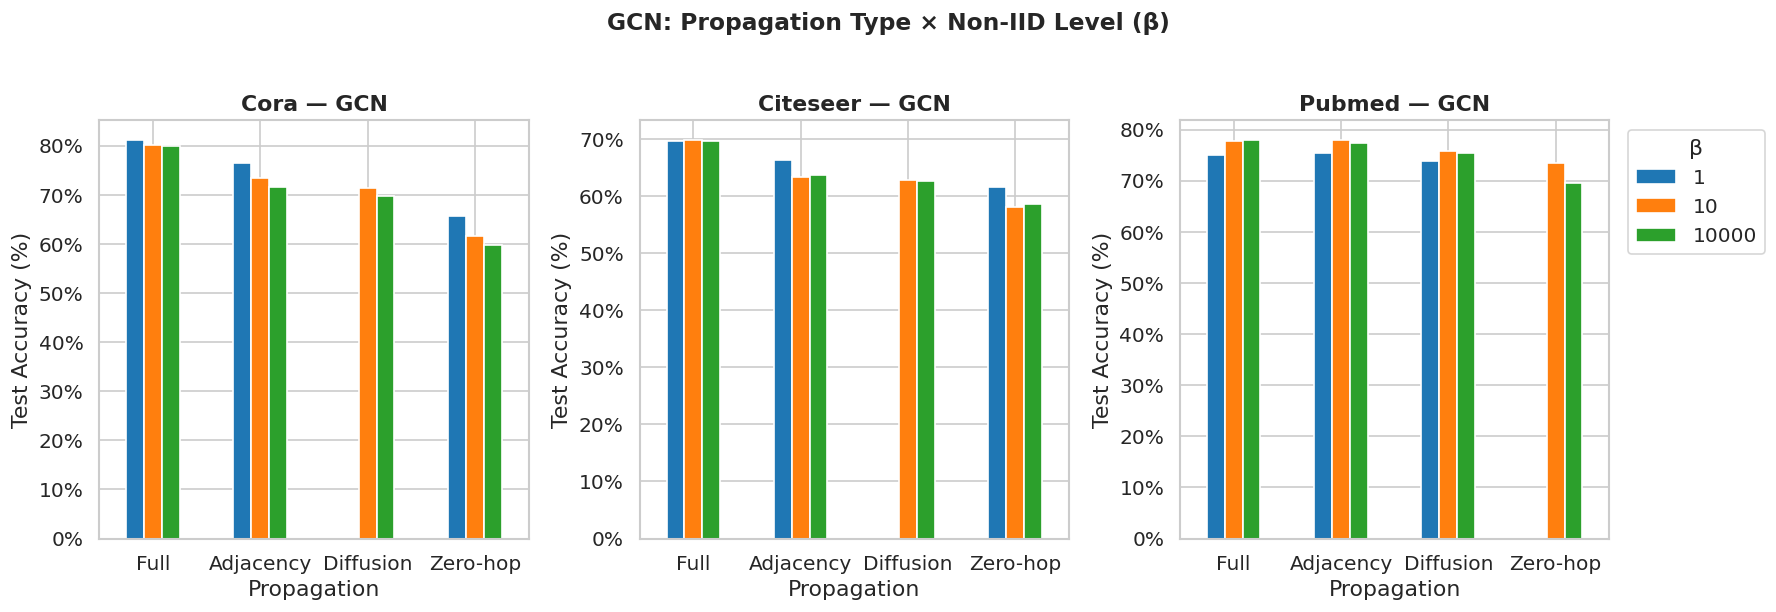

In [10]:
gcn_r1 = r1.copy()
gcn_r1['acc_pct'] = (gcn_r1['mean_acc'] * 100).round(2)
gcn_r1['std_pct'] = (gcn_r1['std_acc']  * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, dataset in zip(axes, DATASET_ORDER):
    sub = gcn_r1[gcn_r1['dataset'] == dataset].copy()
    sub['propagation'] = pd.Categorical(sub['propagation'], categories=PROP_ORDER, ordered=True)
    sub = sub.sort_values(['propagation', 'beta'])

    pivot = sub.pivot_table(index='propagation', columns='beta', values='acc_pct')
    pivot.index = pivot.index.map(PROP_LABELS)

    pivot.plot(kind='bar', ax=ax, rot=0, capsize=4, legend=(dataset == 'Pubmed'))
    ax.set_title(f'{dataset} — GCN', fontweight='bold')
    ax.set_xlabel('Propagation')
    ax.set_ylabel('Test Accuracy (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    if dataset == 'Pubmed':
        ax.legend(title='β', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('GCN: Propagation Type × Non-IID Level (β)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 GAT — accuracy by propagation type (without PE, hop=2)

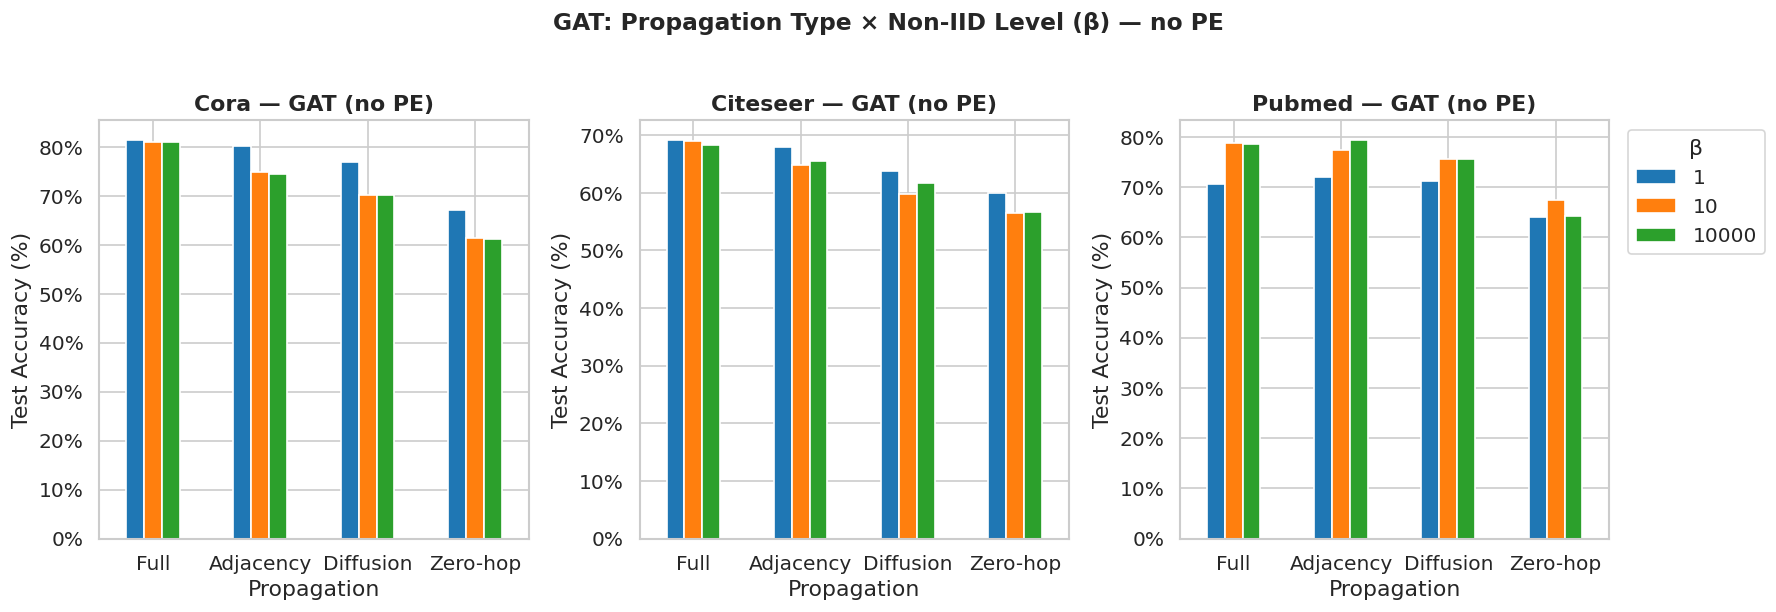

In [11]:
gat_nope = r1b[r1b['use_pe'] == False].copy()
gat_nope['acc_pct'] = (gat_nope['mean_acc'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, dataset in zip(axes, DATASET_ORDER):
    sub = gat_nope[gat_nope['dataset'] == dataset].copy()
    sub['propagation'] = pd.Categorical(sub['propagation'], categories=PROP_ORDER, ordered=True)
    sub = sub.sort_values(['propagation', 'beta'])

    pivot = sub.pivot_table(index='propagation', columns='beta', values='acc_pct')
    pivot.index = pivot.index.map(PROP_LABELS)

    pivot.plot(kind='bar', ax=ax, rot=0, capsize=4, legend=(dataset == 'Pubmed'))
    ax.set_title(f'{dataset} — GAT (no PE)', fontweight='bold')
    ax.set_xlabel('Propagation')
    ax.set_ylabel('Test Accuracy (%)')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))
    if dataset == 'Pubmed':
        ax.legend(title='β', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle('GAT: Propagation Type × Non-IID Level (β) — no PE', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Heatmap — mean accuracy by propagation × dataset (GCN, β=1)

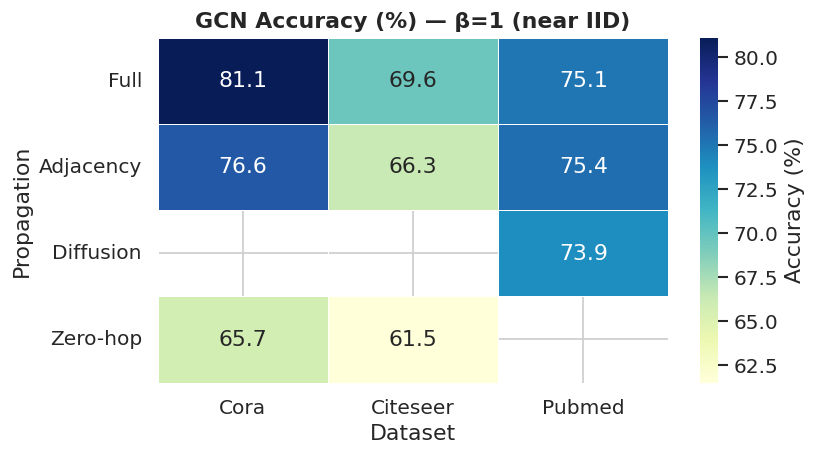

In [12]:
hmap_data = (
    gcn_r1[gcn_r1['beta'] == 1]
    .pivot_table(index='propagation', columns='dataset', values='acc_pct')
    .reindex(index=[p for p in PROP_ORDER if p in gcn_r1['propagation'].unique()],
             columns=DATASET_ORDER)
)
hmap_data.index = [PROP_LABELS.get(p, p) for p in hmap_data.index]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(hmap_data, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=.5,
            ax=ax, cbar_kws={'label': 'Accuracy (%)'})
ax.set_title('GCN Accuracy (%) — β=1 (near IID)', fontweight='bold')
ax.set_xlabel('Dataset')
ax.set_ylabel('Propagation')
plt.tight_layout()
plt.show()

## 5. Non-IID Level (β) Analysis

### 5.1 Accuracy vs β — GCN, per dataset and propagation

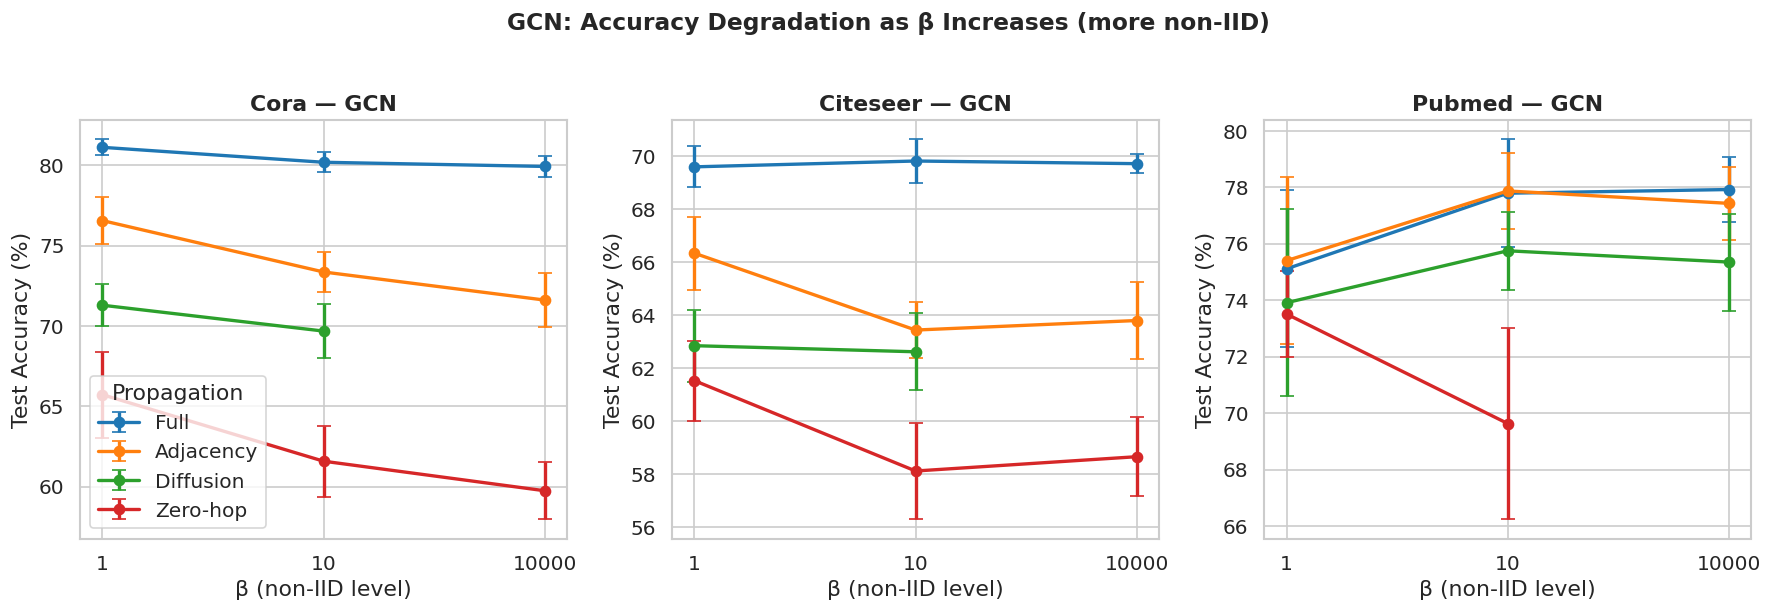

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, dataset in zip(axes, DATASET_ORDER):
    sub = gcn_r1[gcn_r1['dataset'] == dataset]
    for prop in PROP_ORDER:
        rows = sub[sub['propagation'] == prop].sort_values('beta')
        if rows.empty:
            continue
        ax.errorbar(
            range(len(rows)), rows['acc_pct'], yerr=rows['std_pct'],
            label=PROP_LABELS[prop], marker='o', capsize=4,
            color=PROP_COLORS[prop], linewidth=2
        )
    beta_vals = sorted(sub['beta'].unique())
    ax.set_xticks(range(len(beta_vals)))
    ax.set_xticklabels([str(b) for b in beta_vals])
    ax.set_title(f'{dataset} — GCN', fontweight='bold')
    ax.set_xlabel('β (non-IID level)')
    ax.set_ylabel('Test Accuracy (%)')
    if dataset == 'Cora':
        ax.legend(title='Propagation')

plt.suptitle('GCN: Accuracy Degradation as β Increases (more non-IID)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Accuracy drop from β=1 to β=10000 — per propagation and dataset

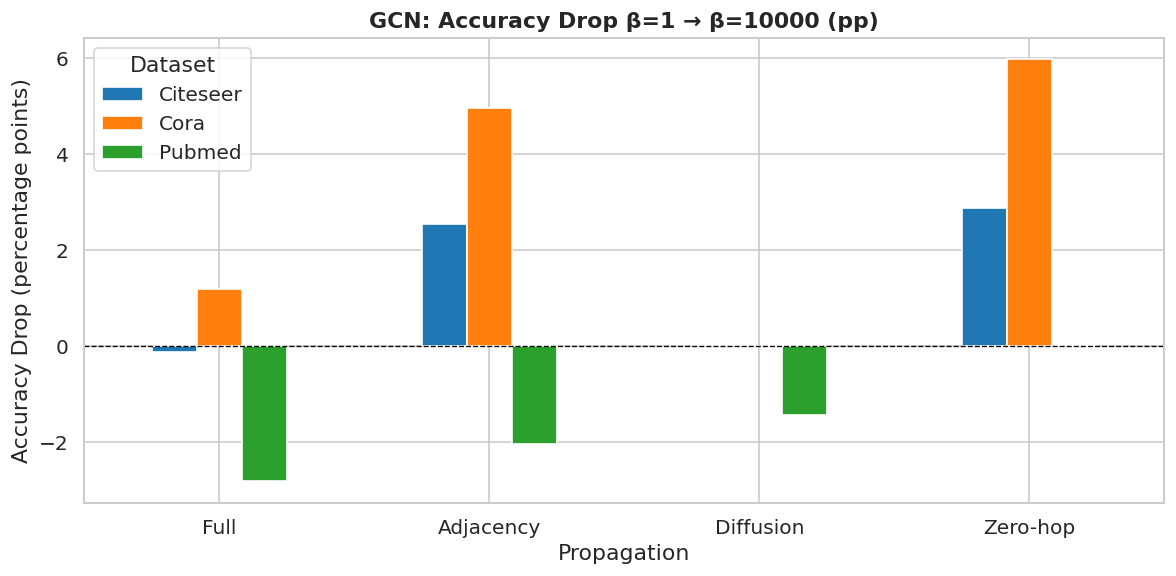

 dataset propagation  acc_b1  acc_b10000  drop_pp
Citeseer        full   69.60       69.72    -0.12
Citeseer   adjacency   66.34       63.80     2.54
Citeseer    zero_hop   61.53       58.66     2.87
    Cora        full   81.12       79.93     1.19
    Cora   adjacency   76.56       71.61     4.95
    Cora    zero_hop   65.72       59.74     5.98
  Pubmed        full   75.11       77.92    -2.81
  Pubmed   adjacency   75.40       77.43    -2.03
  Pubmed   diffusion   73.91       75.35    -1.44


In [14]:
drop_rows = []
for (dataset, prop), grp in gcn_r1.groupby(['dataset', 'propagation']):
    grp = grp.set_index('beta')['acc_pct']
    if 1 in grp.index and 10000 in grp.index:
        drop_rows.append({
            'dataset': dataset,
            'propagation': prop,
            'acc_b1': grp[1],
            'acc_b10000': grp[10000],
            'drop_pp': grp[1] - grp[10000],
        })

drop_df = pd.DataFrame(drop_rows)
drop_df['propagation'] = pd.Categorical(drop_df['propagation'], categories=PROP_ORDER, ordered=True)
drop_df = drop_df.sort_values(['dataset', 'propagation'])

fig, ax = plt.subplots(figsize=(10, 5))
pivot_drop = drop_df.pivot(index='propagation', columns='dataset', values='drop_pp')
pivot_drop.index = pivot_drop.index.map(PROP_LABELS)
pivot_drop.plot(kind='bar', ax=ax, rot=0, color=[COLORS[i] for i in range(3)])
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('GCN: Accuracy Drop β=1 → β=10000 (pp)', fontweight='bold')
ax.set_xlabel('Propagation')
ax.set_ylabel('Accuracy Drop (percentage points)')
ax.legend(title='Dataset')
plt.tight_layout()
plt.show()

print(drop_df[['dataset','propagation','acc_b1','acc_b10000','drop_pp']].to_string(index=False))

## 6. GCN vs GAT Comparison

### 6.1 GCN (hop=1) vs GAT (hop=2, no PE) — best β per propagation

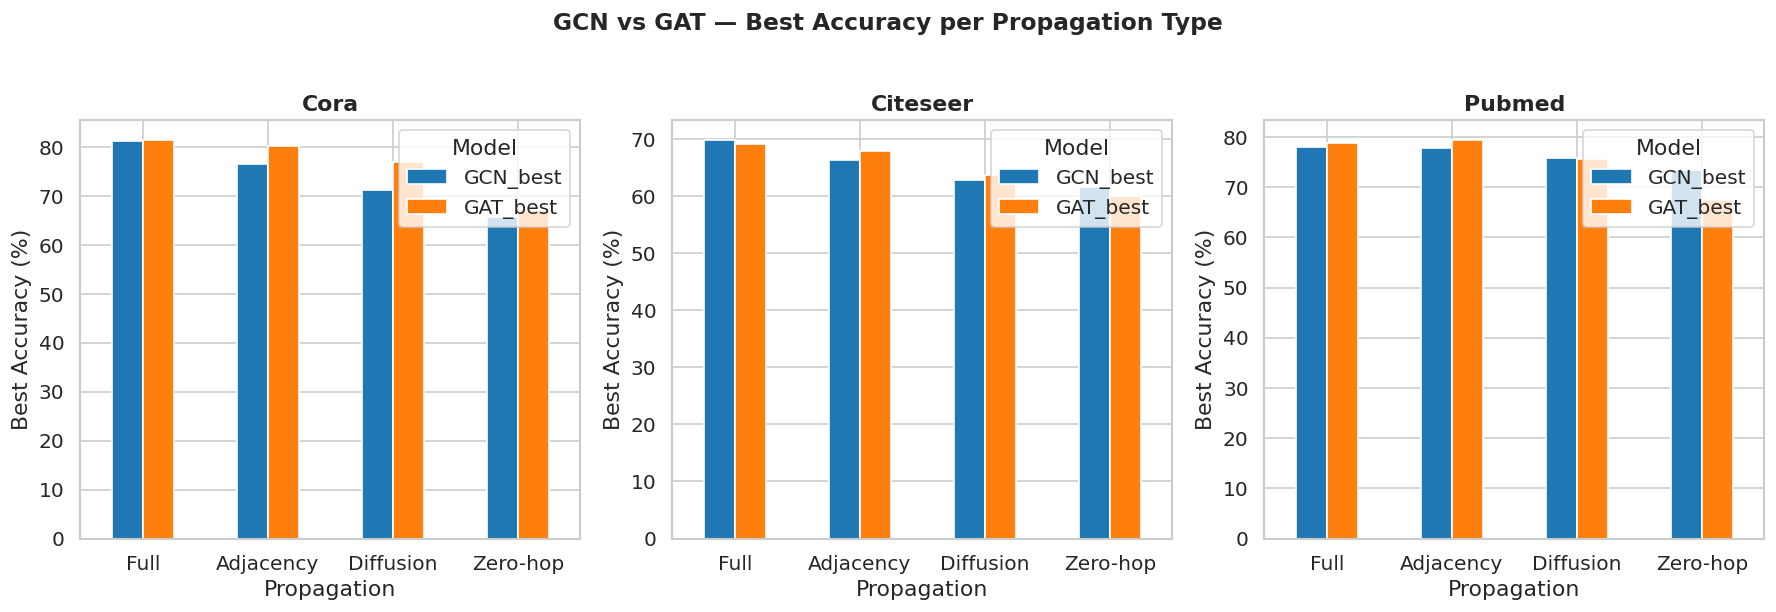

In [15]:
gcn_best = (
    gcn_r1.groupby(['dataset', 'propagation'])['acc_pct']
    .max().reset_index().rename(columns={'acc_pct': 'GCN_best'})
)

gat_best = (
    gat_nope.assign(acc_pct=lambda x: (x['mean_acc']*100).round(2))
    .groupby(['dataset', 'propagation'])['acc_pct']
    .max().reset_index().rename(columns={'acc_pct': 'GAT_best'})
)

model_cmp = gcn_best.merge(gat_best, on=['dataset','propagation'], how='outer')
model_cmp['propagation'] = pd.Categorical(model_cmp['propagation'], categories=PROP_ORDER, ordered=True)
model_cmp = model_cmp.sort_values(['dataset', 'propagation'])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, DATASET_ORDER):
    sub = model_cmp[model_cmp['dataset'] == dataset].set_index('propagation')[['GCN_best', 'GAT_best']]
    sub.index = sub.index.map(PROP_LABELS)
    sub.plot(kind='bar', ax=ax, rot=0, color=[COLORS[0], COLORS[1]])
    ax.set_title(f'{dataset}', fontweight='bold')
    ax.set_xlabel('Propagation')
    ax.set_ylabel('Best Accuracy (%)')
    ax.legend(title='Model')

plt.suptitle('GCN vs GAT — Best Accuracy per Propagation Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Effect of Positional Encoding (PE) on GAT

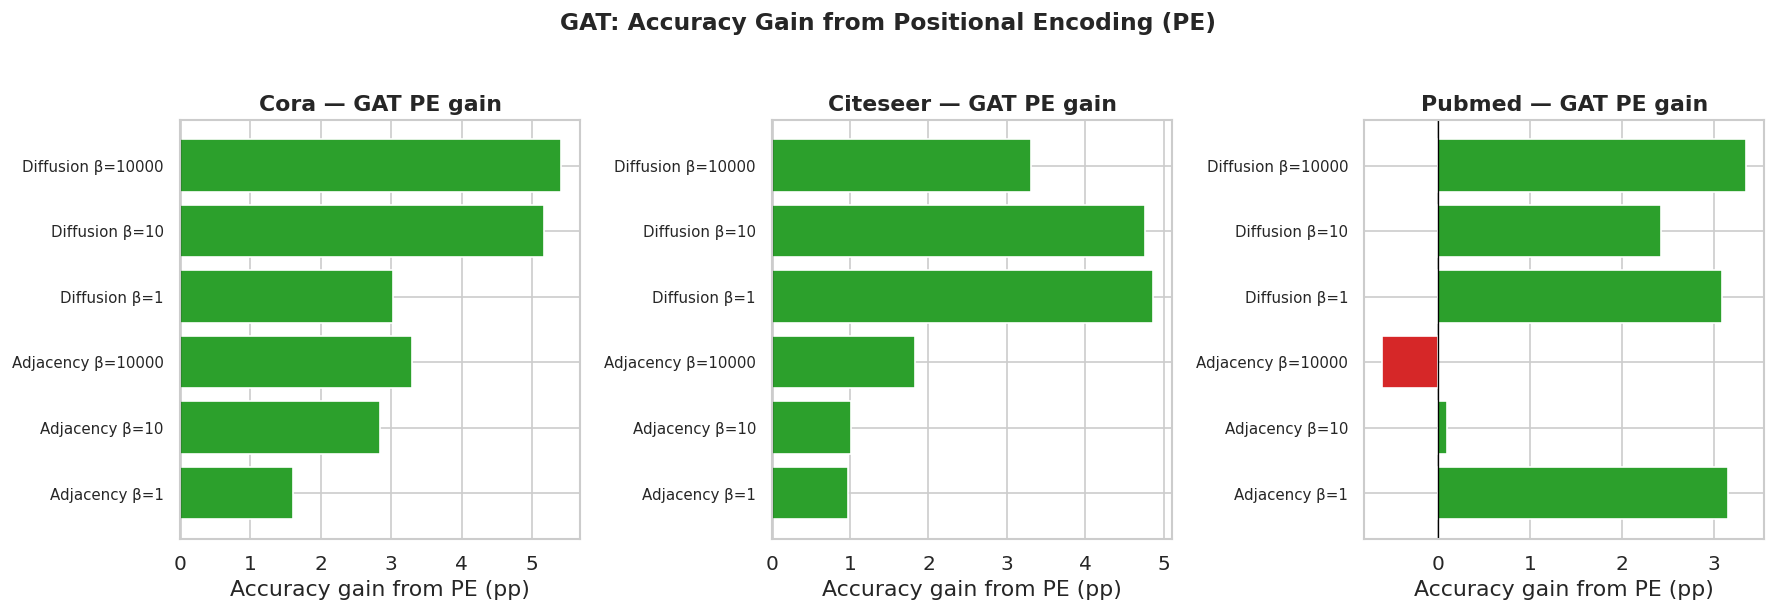


PE gain summary (mean across datasets):
propagation  beta 
adjacency    1        1.91
             10       1.32
             10000    1.51
diffusion    1        3.66
             10       4.12
             10000    4.02


In [16]:
r1b_acc = r1b.copy()
r1b_acc['acc_pct'] = (r1b_acc['mean_acc'] * 100).round(2)
r1b_acc['std_pct'] = (r1b_acc['std_acc']  * 100).round(2)

# PE is only applied to adjacency / diffusion in R1b
pe_props = r1b_acc[r1b_acc['use_pe'] == True]['propagation'].unique()
pe_sub = r1b_acc[r1b_acc['propagation'].isin(pe_props)].copy()

pe_pivot = pe_sub.pivot_table(
    index=['dataset','propagation','beta'], columns='use_pe', values='acc_pct'
).reset_index()
pe_pivot.columns = ['dataset','propagation','beta','no_pe','pe']
pe_pivot['pe_gain'] = (pe_pivot['pe'] - pe_pivot['no_pe']).round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, dataset in zip(axes, DATASET_ORDER):
    sub = pe_pivot[pe_pivot['dataset'] == dataset]
    ax.barh(range(len(sub)), sub['pe_gain'],
            color=[COLORS[2] if g >= 0 else COLORS[3] for g in sub['pe_gain']])
    labels = [f"{PROP_LABELS.get(p,p)} β={b}" for p, b in zip(sub['propagation'], sub['beta'])]
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{dataset} — GAT PE gain', fontweight='bold')
    ax.set_xlabel('Accuracy gain from PE (pp)')

plt.suptitle('GAT: Accuracy Gain from Positional Encoding (PE)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\nPE gain summary (mean across datasets):')
print(pe_pivot.groupby(['propagation','beta'])['pe_gain'].mean().round(2).to_string())

## 7. Summary Heatmaps — All Configurations

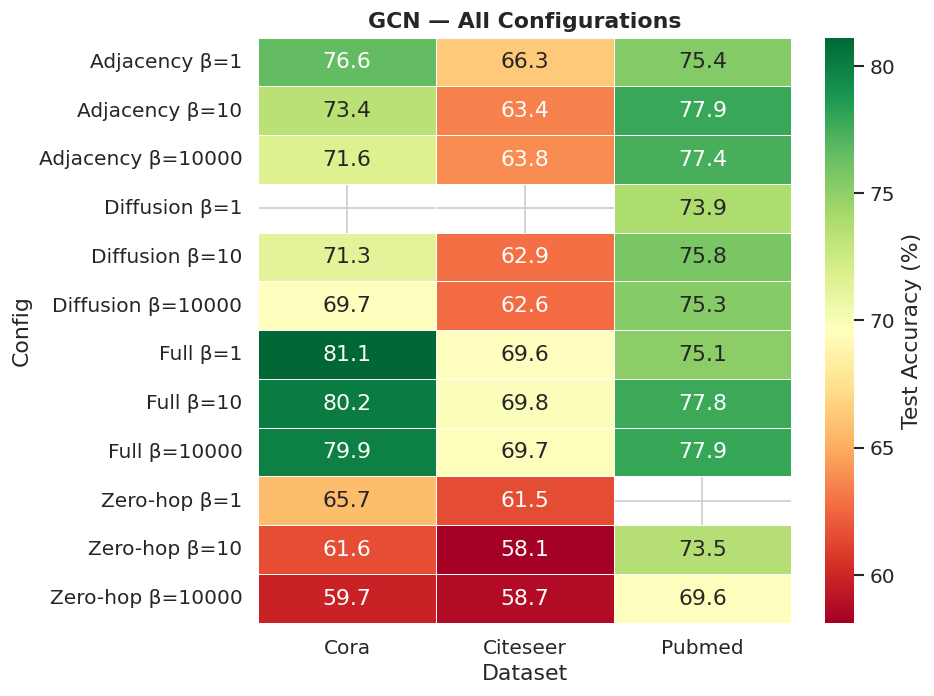

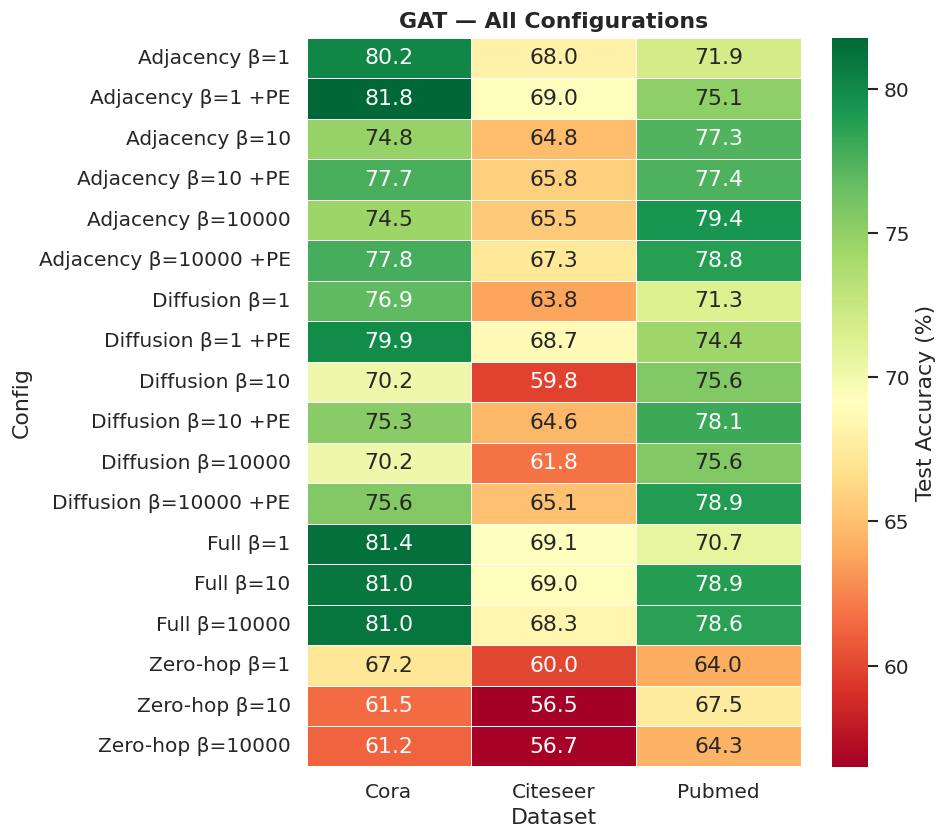

In [17]:
def make_summary_heatmap(df, model_name, title_suffix=''):
    df = df.copy()
    df['config'] = (
        df['propagation'].map(PROP_LABELS).fillna(df['propagation'])
        + ' β=' + df['beta'].astype(str)
        + (df['use_pe'].map({True:' +PE', False:''}) if 'use_pe' in df.columns else '')
    )
    pivot = df.pivot_table(index='config', columns='dataset', values='acc_pct')
    pivot = pivot[DATASET_ORDER]

    fig, ax = plt.subplots(figsize=(8, max(6, len(pivot)*0.4)))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', linewidths=.4,
                ax=ax, cbar_kws={'label': 'Test Accuracy (%)'})
    ax.set_title(f'{model_name} — All Configurations{title_suffix}', fontweight='bold')
    ax.set_xlabel('Dataset')
    ax.set_ylabel('Config')
    plt.tight_layout()
    plt.show()

make_summary_heatmap(gcn_r1, 'GCN')
make_summary_heatmap(r1b_acc, 'GAT')

## 8. Per-Dataset Deep Dive

In [18]:
for dataset in DATASET_ORDER:
    print(f'\n{'='*60}')
    print(f'  {dataset.upper()}')
    print(f"{'='*60}")
    print('\n-- GCN --')
    gcn_ds = gcn_r1[gcn_r1['dataset'] == dataset][['propagation','beta','hop','acc_pct','std_pct']]
    gcn_ds = gcn_ds.sort_values('acc_pct', ascending=False)
    print(gcn_ds.to_string(index=False))

    print('\n-- GAT --')
    gat_ds = r1b_acc[r1b_acc['dataset'] == dataset][['propagation','beta','use_pe','hop','acc_pct','std_pct']]
    gat_ds = gat_ds.sort_values('acc_pct', ascending=False)
    print(gat_ds.to_string(index=False))


  CORA

-- GCN --
propagation  beta  hop  acc_pct  std_pct
       full     1    1    81.12     0.50
       full    10    1    80.19     0.63
       full 10000    1    79.93     0.65
  adjacency     1    1    76.56     1.47
  adjacency    10    1    73.36     1.22
  adjacency 10000    1    71.61     1.67
  diffusion    10    1    71.29     1.31
  diffusion 10000    1    69.68     1.68
   zero_hop     1    1    65.72     2.68
   zero_hop    10    1    61.58     2.22
   zero_hop 10000    1    59.74     1.79

-- GAT --
propagation  beta  use_pe  hop  acc_pct  std_pct
  adjacency     1    True    2    81.78     0.86
       full     1   False    2    81.38     0.63
       full 10000   False    2    81.05     0.86
       full    10   False    2    80.98     0.91
  adjacency     1   False    2    80.18     0.75
  diffusion     1    True    2    79.90     0.62
  adjacency 10000    True    2    77.83     0.80
  adjacency    10    True    2    77.67     1.30
  diffusion     1   False    2    76.

## 9. Training Curves (Prelim Runs)

### 9.1 Load and parse training curves from a selected experiment

In [19]:
def load_training_curves(csv_path):
    """Return a dict {client_id: {'train_loss': [...], 'train_acc': [...], 'val_loss': [...]}}"""
    df = pd.read_csv(csv_path)
    clients = {}
    for _, row in df.iterrows():
        cid = int(row['client_id'])
        try:
            clients[cid] = {
                'train_loss': ast.literal_eval(row['training_losses']),
                'train_acc':  ast.literal_eval(row['training_accuracies']),
                'val_loss':   ast.literal_eval(row['validation_losses']),
            }
        except Exception:
            pass
    return clients

def plot_training_curves(csv_path, title=''):
    clients = load_training_curves(csv_path)
    if not clients:
        print(f'No curve data in {csv_path}')
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for cid, data in clients.items():
        alpha = 0.6
        if data.get('train_loss'):
            axes[0].plot(data['train_loss'], alpha=alpha, linewidth=1)
        if data.get('train_acc'):
            axes[1].plot(data['train_acc'], alpha=alpha, linewidth=1)

    axes[0].set_title('Training Loss per Client')
    axes[0].set_xlabel('Round')
    axes[0].set_ylabel('Loss')

    axes[1].set_title('Training Accuracy per Client')
    axes[1].set_xlabel('Round')
    axes[1].set_ylabel('Accuracy')

    plt.suptitle(title, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

print('Training curve loader ready.')

Training curve loader ready.


### 9.2 Compare training curves across propagation types — Cora, GCN

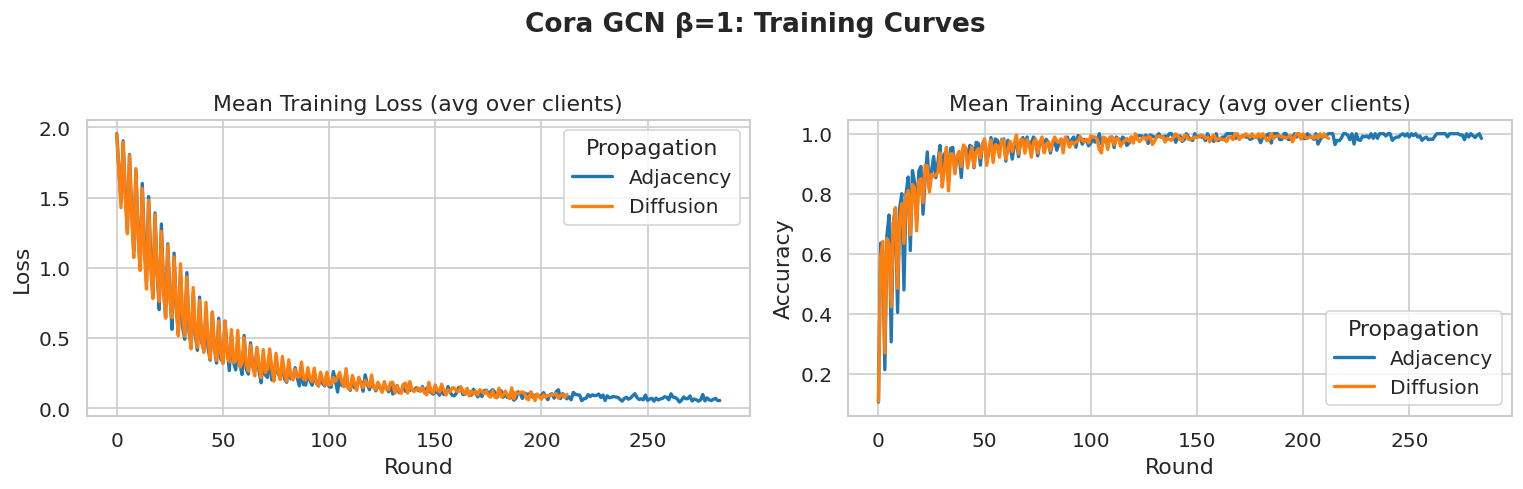

In [20]:
# Pick one representative run per propagation for Cora GCN, beta=1, no PE
target_dataset = 'Cora'
target_model   = 'GCN'
target_beta    = 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prop in ['adjacency', 'diffusion']:
    rows = prelim_df[
        (prelim_df['dataset']      == target_dataset) &
        (prelim_df['model']        == target_model) &
        (prelim_df['propagation']  == prop) &
        (prelim_df['beta']         == target_beta) &
        (prelim_df['use_pe']       == False)
    ]
    if rows.empty:
        print(f'  No row for {prop}')
        continue

    csv_path = rows.iloc[0]['csv_path']
    clients  = load_training_curves(csv_path)
    if not clients:
        continue

    # Average over clients
    all_losses = [c['train_loss'] for c in clients.values() if c.get('train_loss')]
    all_accs   = [c['train_acc']  for c in clients.values() if c.get('train_acc')]
    min_len_l  = min(len(x) for x in all_losses) if all_losses else 0
    min_len_a  = min(len(x) for x in all_accs)   if all_accs   else 0

    if min_len_l:
        mean_loss = np.mean([x[:min_len_l] for x in all_losses], axis=0)
        axes[0].plot(mean_loss, label=PROP_LABELS[prop], linewidth=2)
    if min_len_a:
        mean_acc  = np.mean([x[:min_len_a] for x in all_accs], axis=0)
        axes[1].plot(mean_acc, label=PROP_LABELS[prop], linewidth=2)

for ax in axes:
    ax.legend(title='Propagation')
    ax.set_xlabel('Round')

axes[0].set_title('Mean Training Loss (avg over clients)')
axes[0].set_ylabel('Loss')
axes[1].set_title('Mean Training Accuracy (avg over clients)')
axes[1].set_ylabel('Accuracy')

plt.suptitle(f'{target_dataset} {target_model} β={target_beta}: Training Curves', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Interactive: plot curves for any single experiment

Showing: Citeseer GCN diffusion β=10000 PE=True  |  final acc ≈ 100.0%


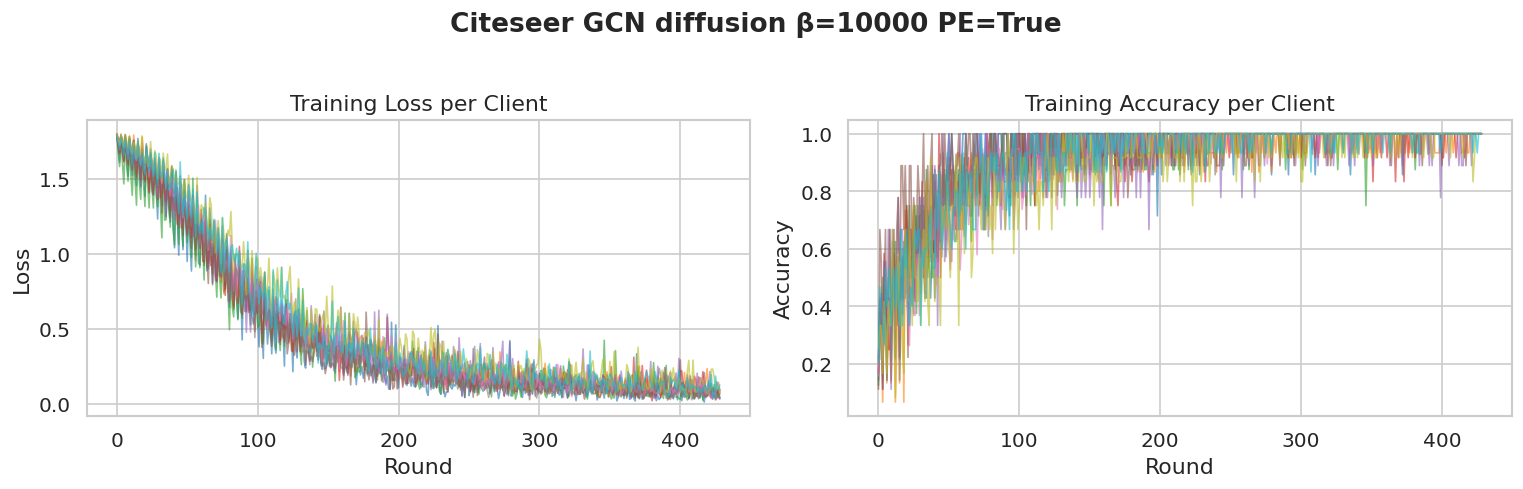

In [21]:
# Change parameters below to explore any run
QUERY = dict(dataset='Citeseer', model='GCN', propagation='diffusion', beta=10000, use_pe=True)

mask = pd.Series([True] * len(prelim_df))
for k, v in QUERY.items():
    if k in prelim_df.columns:
        mask &= (prelim_df[k] == v)

hits = prelim_df[mask]
if hits.empty:
    print('No matching run found. Adjust QUERY above.')
else:
    row = hits.iloc[0]
    label = f"{row['dataset']} {row['model']} {row['propagation']} β={row['beta']} PE={row['use_pe']}"
    print(f'Showing: {label}  |  final acc ≈ {row["acc_pct"]}%')
    plot_training_curves(row['csv_path'], title=label)

## 10. Propagator Evaluation

### 10.1 Propagator convergence — normalized residuals (β=10000)

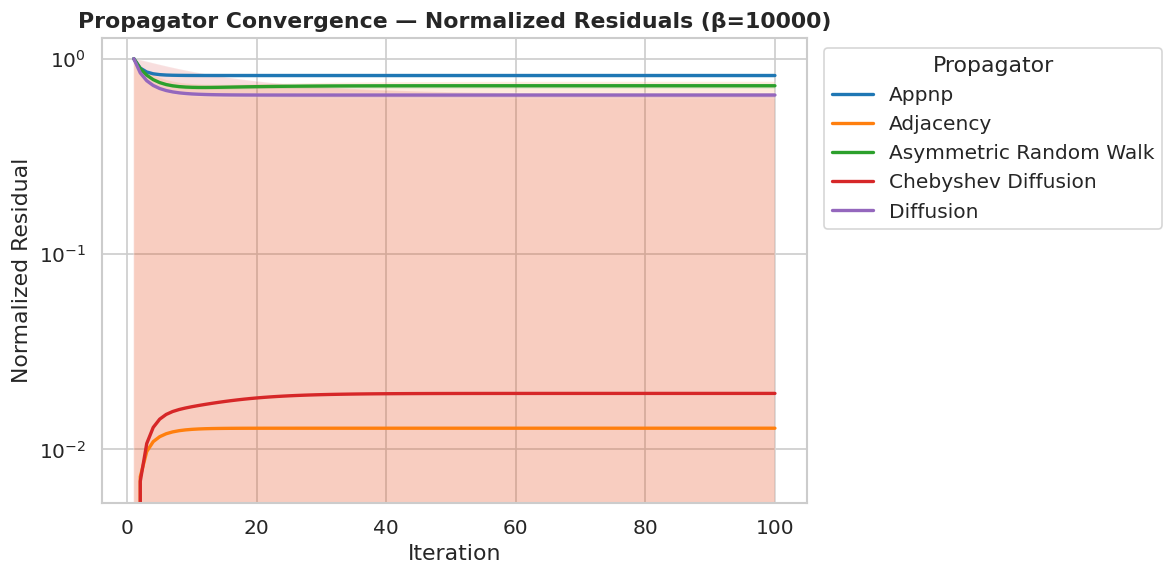

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

mean_cols = [c for c in norm_resid.columns if c.endswith('_mean')]
std_cols  = [c for c in norm_resid.columns if c.endswith('_std')]

for mc in mean_cols:
    sc = mc.replace('_mean', '_std')
    label = mc.replace('_mean', '').replace('_', ' ').title()
    y     = norm_resid[mc]
    x     = norm_resid['iter']
    ax.plot(x, y, label=label, linewidth=2)
    if sc in norm_resid.columns:
        ax.fill_between(x, y - norm_resid[sc], y + norm_resid[sc], alpha=0.15)

ax.set_xlabel('Iteration')
ax.set_ylabel('Normalized Residual')
ax.set_title('Propagator Convergence — Normalized Residuals (β=10000)', fontweight='bold')
ax.legend(title='Propagator', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

### 10.2 β sensitivity — APPNP convergence across β values

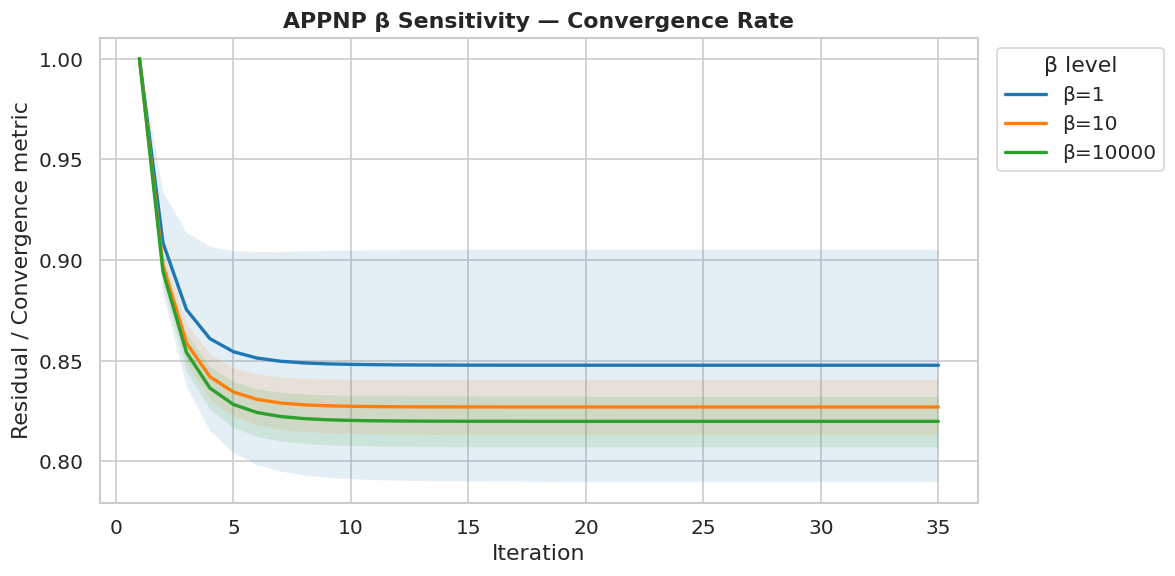

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

beta_mean_cols = [c for c in beta_sens.columns if c.endswith('_mean')]
beta_std_cols  = [c for c in beta_sens.columns if c.endswith('_std')]

for mc in beta_mean_cols:
    sc    = mc.replace('_mean', '_std')
    label = mc.replace('_mean', '').replace('beta', 'β=')
    y     = beta_sens[mc]
    x     = beta_sens['iter']
    ax.plot(x, y, label=label, linewidth=2)
    if sc in beta_sens.columns:
        ax.fill_between(x, y - beta_sens[sc], y + beta_sens[sc], alpha=0.12)

ax.set_xlabel('Iteration')
ax.set_ylabel('Residual / Convergence metric')
ax.set_title('APPNP β Sensitivity — Convergence Rate', fontweight='bold')
ax.legend(title='β level', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 10.3 Raw vs Normalized residuals — side by side

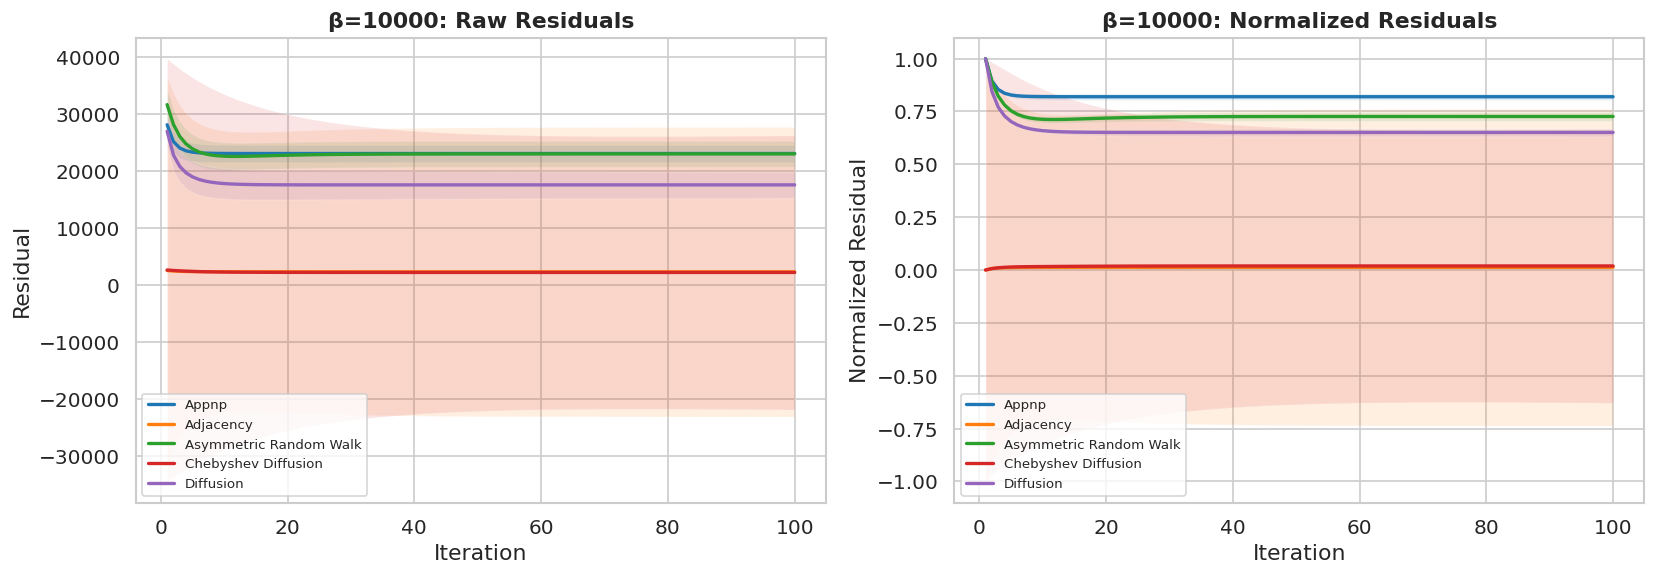

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, ylabel, title in [
    (axes[0], raw_resid,  'Residual',            'Raw Residuals'),
    (axes[1], norm_resid, 'Normalized Residual', 'Normalized Residuals'),
]:
    mean_c = [c for c in df.columns if c.endswith('_mean')]
    for mc in mean_c:
        sc    = mc.replace('_mean', '_std')
        label = mc.replace('_mean', '').replace('_', ' ').title()
        y, x  = df[mc], df['iter']
        ax.plot(x, y, label=label, linewidth=2)
        if sc in df.columns:
            ax.fill_between(x, y - df[sc], y + df[sc], alpha=0.12)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.set_title(f'β=10000: {title}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 11. Key Takeaways

In [25]:
print('=== BEST RESULTS SUMMARY ===')
best_overall = (
    consolidated
    .sort_values('acc_pct', ascending=False)
    .groupby('dataset')
    .first()
    [['model', 'propagation', 'beta', 'hop', 'use_pe', 'acc_pct', 'std_pct']]
    .reset_index()
)
print(best_overall.to_string(index=False))

print('\n=== AVERAGE ACCURACY BY PROPAGATION TYPE (GCN) ===')
avg_by_prop = (
    gcn_r1.groupby('propagation')['acc_pct']
    .agg(['mean','std'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print(avg_by_prop.to_string())

print('\n=== AVERAGE ACCURACY BY PROPAGATION TYPE (GAT, no PE) ===')
avg_by_prop_gat = (
    gat_nope.assign(acc_pct=lambda x: (x['mean_acc']*100).round(2))
    .groupby('propagation')['acc_pct']
    .agg(['mean','std'])
    .round(2)
    .sort_values('mean', ascending=False)
)
print(avg_by_prop_gat.to_string())

=== BEST RESULTS SUMMARY ===
 dataset model propagation  beta  hop  use_pe  acc_pct  std_pct
Citeseer   GCN        full    10    1   False    69.82     0.82
    Cora   GAT   adjacency     1    2    True    81.78     0.86
  Pubmed   GAT   adjacency 10000    2   False    79.36     0.60

=== AVERAGE ACCURACY BY PROPAGATION TYPE (GCN) ===
              mean   std
propagation             
full         75.69  4.80
adjacency    71.76  5.81
diffusion    70.21  5.54
zero_hop     63.56  5.56

=== AVERAGE ACCURACY BY PROPAGATION TYPE (GAT, no PE) ===
              mean   std
propagation             
full         75.34  5.85
adjacency    72.94  5.77
diffusion    69.46  6.32
zero_hop     62.09  4.03
